# Earthquake Epicentre Clustering by Magnitude and Depth

This notebook performs unsupervised clustering on earthquake data to identify natural groupings based on magnitude, depth, and location. We apply multiple clustering algorithms (K-Means, Hierarchical, DBSCAN, GMM) and compare their performance using standard clustering evaluation metrics.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load earthquake data
df = pd.read_csv('earthquake_data.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nData description:')
print(df.describe())

Dataset shape: (500, 6)

First 5 rows:
   earthquake_id  magnitude      depth   latitude   longitude  \
0              1   5.798028  46.704922  33.550637  137.414959   
1              2   5.417041  55.356689  37.074169  138.770527   
2              3   5.888613  72.168411  37.817191  140.009975   
3              4   6.413818  42.225947  33.858635  140.731510   
4              5   5.359508  37.872596  37.426752  136.599407   

              true_cluster  
0  Shallow Subduction Zone  
1  Shallow Subduction Zone  
2  Shallow Subduction Zone  
3  Shallow Subduction Zone  
4  Shallow Subduction Zone  

Data description:
       earthquake_id   magnitude       depth    latitude   longitude
count     500.000000  500.000000  500.000000  500.000000  500.000000
mean      250.500000    5.954022  168.391457   36.241035  140.318275
std       144.481833    1.112529  171.151958    4.477220    4.956426
min         1.000000    3.700597    5.000000   26.483839  130.298057
25%       125.750000    5.045052

In [3]:
# Feature engineering and preprocessing
# Select features for clustering: magnitude, depth, latitude, longitude
features = ['magnitude', 'depth', 'latitude', 'longitude']
X = df[features].copy()

# Check for missing values
print(f'Missing values:\n{X.isnull().sum()}')

# Handle any missing values (if present)
X = X.dropna()

# Standardize features (critical for distance-based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nScaled data shape: {X_scaled.shape}')
print(f'Scaled data mean (should be ~0): {X_scaled.mean(axis=0)}')
print(f'Scaled data std (should be ~1): {X_scaled.std(axis=0)}')

Missing values:
magnitude    0
depth        0
latitude     0
longitude    0
dtype: int64

Scaled data shape: (500, 4)
Scaled data mean (should be ~0): [ 5.40012479e-16  5.68434189e-17 -1.13686838e-16 -5.13011855e-15]
Scaled data std (should be ~1): [1. 1. 1. 1.]


In [4]:
# 1) K-Means with Elbow Method
print('=== K-Means Elbow Method ===')

inertias = []
silhouette_scores_km = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores_km.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f'k={k}: Inertia={kmeans.inertia_:.3f}, Silhouette={silhouette_scores_km[-1]:.3f}')

# Choose optimal k (typically at elbow point, k=4 is common for earthquake data)
optimal_k = 4
print(f'\nSelected k={optimal_k} for further analysis')

=== K-Means Elbow Method ===
k=2: Inertia=951.440, Silhouette=0.440
k=3: Inertia=712.699, Silhouette=0.361
k=4: Inertia=604.191, Silhouette=0.339
k=5: Inertia=527.224, Silhouette=0.320
k=6: Inertia=474.557, Silhouette=0.319
k=7: Inertia=437.536, Silhouette=0.293
k=8: Inertia=406.686, Silhouette=0.291
k=9: Inertia=382.092, Silhouette=0.284
k=10: Inertia=360.473, Silhouette=0.284

Selected k=4 for further analysis


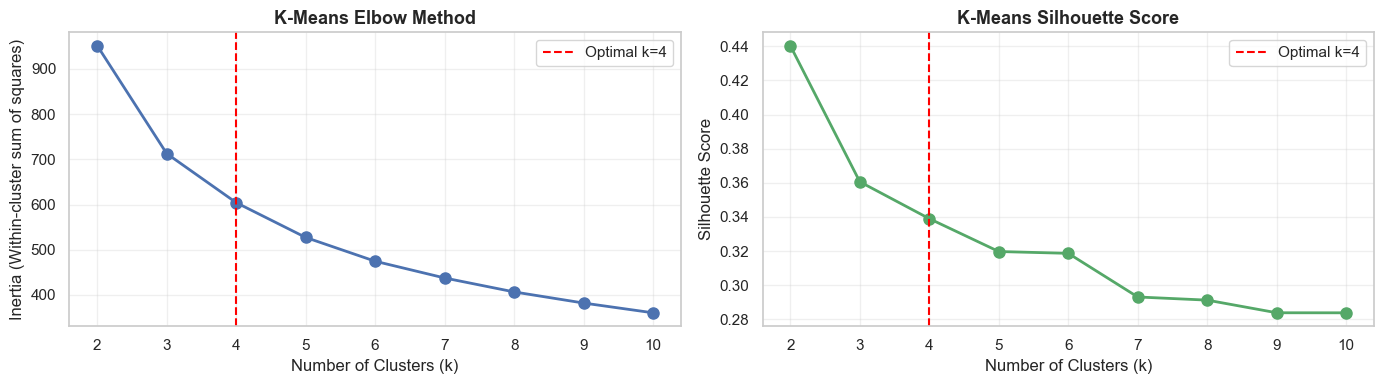

Saved: elbow_silhouette_plot.png


In [5]:
# Elbow plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Inertia plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0].set_title('K-Means Elbow Method', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette scores
axes[1].plot(k_range, silhouette_scores_km, 'go-', linewidth=2, markersize=8)
axes[1].axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('K-Means Silhouette Score', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: elbow_silhouette_plot.png')

In [6]:
# 2) Train final K-Means model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# 3) Hierarchical Clustering with Dendrogram
print('\n=== Hierarchical Clustering ===')
linkage_matrix = linkage(X_scaled, method='ward')
hierarchical_labels = fcluster(linkage_matrix, optimal_k, criterion='maxclust') - 1

# 4) DBSCAN (for comparison; requires tuning eps and min_samples)
print('\n=== DBSCAN ===')
eps = 0.5  # Adjust based on data characteristics
min_samples = 5
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)
print(f'eps={eps}, min_samples={min_samples}')
print(f'Number of clusters: {n_clusters_dbscan}')
print(f'Number of noise points: {n_noise_dbscan}')

# 5) Gaussian Mixture Model (GMM)
print('\n=== Gaussian Mixture Model ===')
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
print(f'Log-likelihood: {gmm.score(X_scaled):.3f}')
print(f'BIC: {gmm.bic(X_scaled):.3f}')


=== Hierarchical Clustering ===

=== DBSCAN ===
eps=0.5, min_samples=5
Number of clusters: 6
Number of noise points: 188

=== Gaussian Mixture Model ===
Log-likelihood: -3.505
BIC: 3871.420


In [7]:
# Evaluation metrics for all algorithms
print('\n=== Clustering Evaluation Metrics ===')

algorithms = {
    'K-Means': kmeans_labels,
    'Hierarchical': hierarchical_labels,
    'GMM': gmm_labels
}

results = []
for algo_name, labels in algorithms.items():
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    
    results.append({
        'Algorithm': algo_name,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies_bouldin,
        'Calinski-Harabasz Index': calinski_harabasz,
        'Labels': labels
    })
    
    print(f'\n{algo_name}:')
    print(f'  Silhouette Score: {silhouette:.4f} (higher is better, range: -1 to 1)')
    print(f'  Davies-Bouldin Index: {davies_bouldin:.4f} (lower is better)')
    print(f'  Calinski-Harabasz Index: {calinski_harabasz:.4f} (higher is better)')

# Add DBSCAN if valid
if n_clusters_dbscan > 0:
    silhouette_dbscan = silhouette_score(X_scaled, dbscan_labels)
    davies_bouldin_dbscan = davies_bouldin_score(X_scaled, dbscan_labels)
    calinski_harabasz_dbscan = calinski_harabasz_score(X_scaled, dbscan_labels)
    
    print(f'\nDBSCAN (eps={eps}, min_samples={min_samples}):')
    print(f'  Silhouette Score: {silhouette_dbscan:.4f}')
    print(f'  Davies-Bouldin Index: {davies_bouldin_dbscan:.4f}')
    print(f'  Calinski-Harabasz Index: {calinski_harabasz_dbscan:.4f}')
    print(f'  Clusters: {n_clusters_dbscan}, Noise points: {n_noise_dbscan}')

results_df = pd.DataFrame(results)
print(f'\n{results_df.to_string(index=False)}')


=== Clustering Evaluation Metrics ===

K-Means:
  Silhouette Score: 0.3390 (higher is better, range: -1 to 1)
  Davies-Bouldin Index: 1.2568 (lower is better)
  Calinski-Harabasz Index: 381.9546 (higher is better)

Hierarchical:
  Silhouette Score: 0.3045 (higher is better, range: -1 to 1)
  Davies-Bouldin Index: 1.3005 (lower is better)
  Calinski-Harabasz Index: 350.5226 (higher is better)

GMM:
  Silhouette Score: 0.3119 (higher is better, range: -1 to 1)
  Davies-Bouldin Index: 1.3758 (lower is better)
  Calinski-Harabasz Index: 340.2034 (higher is better)

DBSCAN (eps=0.5, min_samples=5):
  Silhouette Score: 0.0690
  Davies-Bouldin Index: 1.6120
  Calinski-Harabasz Index: 98.5963
  Clusters: 6, Noise points: 188

   Algorithm  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index                                                                                                                                                                                                  

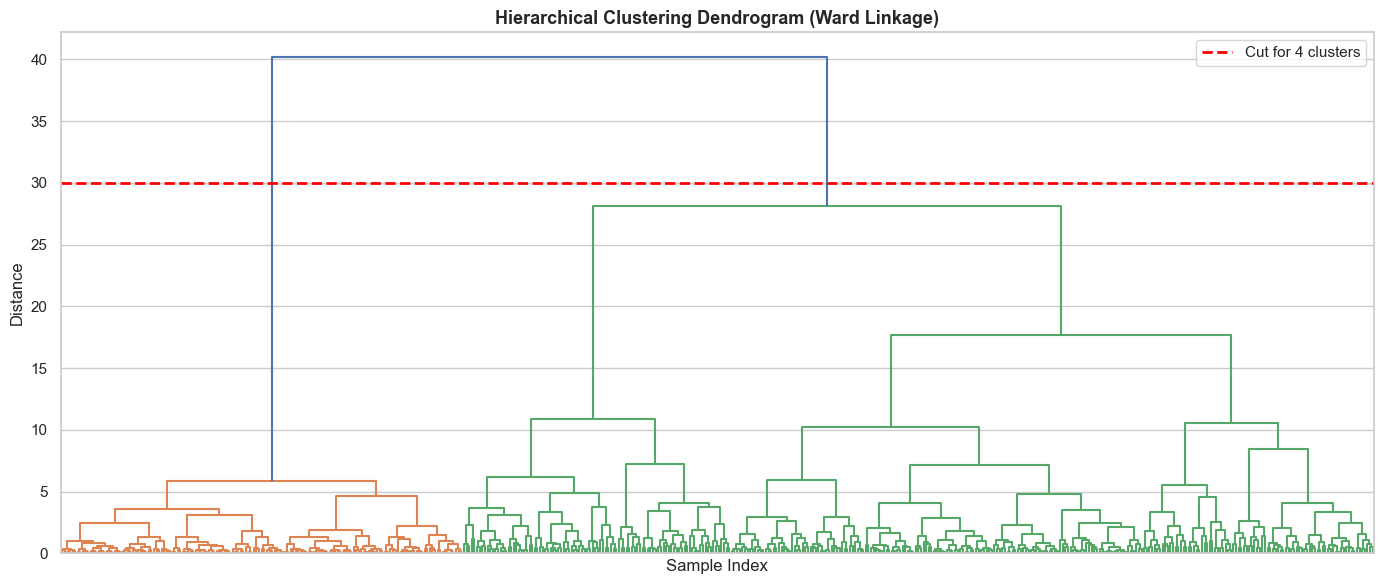

Saved: dendrogram.png


In [8]:
# Dendrogram for Hierarchical Clustering
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, no_labels=True, color_threshold=30)
plt.axhline(y=30, color='red', linestyle='--', linewidth=2, label=f'Cut for {optimal_k} clusters')
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: dendrogram.png')

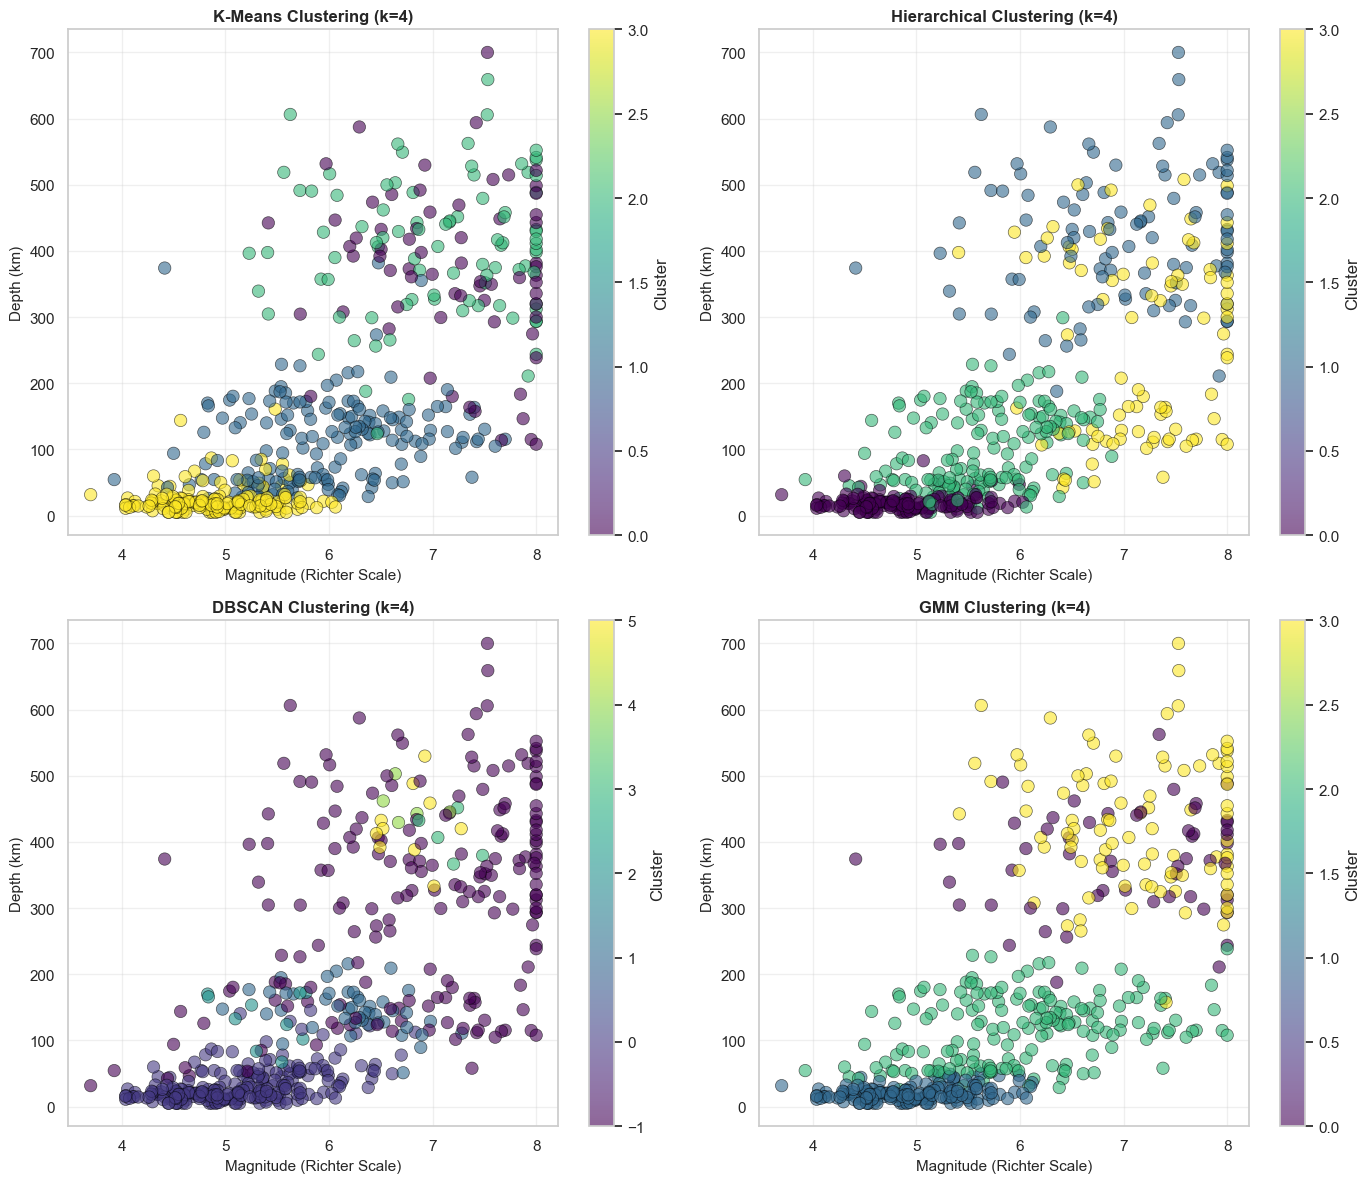

Saved: cluster_scatter_magnitude_depth.png


In [9]:
# Cluster scatter plots - Magnitude vs Depth
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

titles = ['K-Means', 'Hierarchical', 'DBSCAN', 'GMM']
labels_list = [kmeans_labels, hierarchical_labels, dbscan_labels, gmm_labels]

for idx, (ax, title, labels) in enumerate(zip(axes.flat, titles, labels_list)):
    scatter = ax.scatter(df['magnitude'], df['depth'], c=labels, cmap='viridis', s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Magnitude (Richter Scale)', fontsize=11)
    ax.set_ylabel('Depth (km)', fontsize=11)
    ax.set_title(f'{title} Clustering (k={optimal_k})', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.savefig('cluster_scatter_magnitude_depth.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: cluster_scatter_magnitude_depth.png')

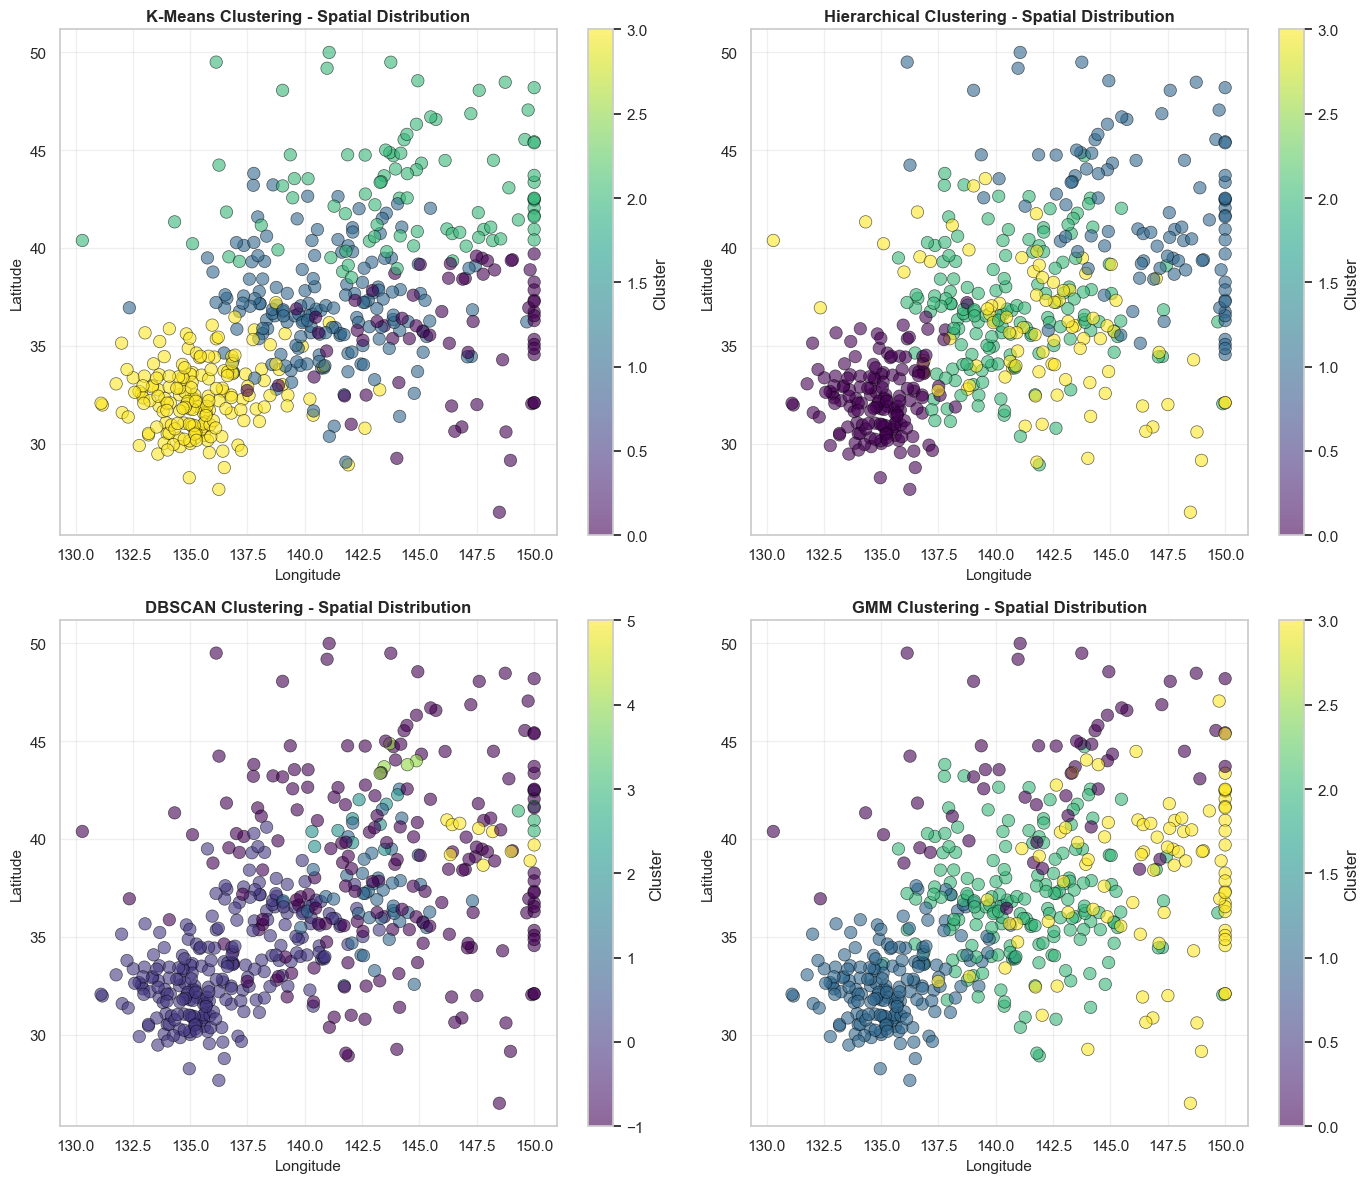

Saved: cluster_scatter_spatial.png


In [10]:
# Spatial scatter plots - Latitude vs Longitude
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for idx, (ax, title, labels) in enumerate(zip(axes.flat, titles, labels_list)):
    scatter = ax.scatter(df['longitude'], df['latitude'], c=labels, cmap='viridis', s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.set_title(f'{title} Clustering - Spatial Distribution', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
plt.savefig('cluster_scatter_spatial.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: cluster_scatter_spatial.png')

In [11]:
# K-Means cluster centres
print('\n=== K-Means Cluster Centres (Scaled) ===')
centres_scaled = kmeans_final.cluster_centers_
centres_original = scaler.inverse_transform(centres_scaled)

centres_df = pd.DataFrame(centres_original, columns=features)
centres_df['Cluster'] = range(optimal_k)
print(centres_df.to_string(index=False))

# Cluster sizes for K-Means
print('\n=== K-Means Cluster Sizes ===')
unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f'Cluster {cluster_id}: {count} earthquakes ({100*count/len(kmeans_labels):.1f}%)')


=== K-Means Cluster Centres (Scaled) ===
 magnitude      depth  latitude  longitude  Cluster
  7.183758 369.466847 35.507675 146.170770        0
  5.975386 113.787772 36.951428 140.886308        1
  7.042115 403.955212 43.065421 144.246788        2
  4.909201  23.198426 32.356403 135.542451        3

=== K-Means Cluster Sizes ===
Cluster 0: 67 earthquakes (13.4%)
Cluster 1: 167 earthquakes (33.4%)
Cluster 2: 90 earthquakes (18.0%)
Cluster 3: 176 earthquakes (35.2%)


In [12]:
# Interpretation and baseline comparison
print('\n=== Clustering Quality Assessment ===')

# Random baseline (assuming random assignment)
random_labels = np.random.randint(0, optimal_k, size=len(X_scaled))
random_silhouette = silhouette_score(X_scaled, random_labels)
print(f'Random clustering Silhouette Score: {random_silhouette:.4f}')
print(f'K-Means Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Improvement over random: {silhouette_score(X_scaled, kmeans_labels) - random_silhouette:.4f}')

# Cluster characteristics
print('\n=== Cluster Characteristics (K-Means) ===')
for cluster_id in range(optimal_k):
    cluster_mask = kmeans_labels == cluster_id
    cluster_data = df[cluster_mask]
    print(f'\nCluster {cluster_id}:')
    print(f'  Avg Magnitude: {cluster_data["magnitude"].mean():.2f} ± {cluster_data["magnitude"].std():.2f}')
    print(f'  Avg Depth: {cluster_data["depth"].mean():.1f} ± {cluster_data["depth"].std():.1f} km')
    print(f'  Magnitude Range: {cluster_data["magnitude"].min():.2f} - {cluster_data["magnitude"].max():.2f}')
    print(f'  Depth Range: {cluster_data["depth"].min():.1f} - {cluster_data["depth"].max():.1f} km')


=== Clustering Quality Assessment ===
Random clustering Silhouette Score: -0.0332
K-Means Silhouette Score: 0.3390
Improvement over random: 0.3722

=== Cluster Characteristics (K-Means) ===

Cluster 0:
  Avg Magnitude: 7.18 ± 0.70
  Avg Depth: 369.5 ± 123.0 km
  Magnitude Range: 5.42 - 8.00
  Depth Range: 107.9 - 700.0 km

Cluster 1:
  Avg Magnitude: 5.98 ± 0.73
  Avg Depth: 113.8 ± 64.5 km
  Magnitude Range: 3.93 - 7.70
  Depth Range: 21.2 - 382.0 km

Cluster 2:
  Avg Magnitude: 7.04 ± 0.80
  Avg Depth: 404.0 ± 102.7 km
  Magnitude Range: 5.23 - 8.00
  Depth Range: 123.9 - 659.0 km

Cluster 3:
  Avg Magnitude: 4.91 ± 0.47
  Avg Depth: 23.2 ± 21.2 km
  Magnitude Range: 3.70 - 6.06
  Depth Range: 5.0 - 160.8 km


In [13]:
# Summary output for report
summary = {
    'dataset_size': len(df),
    'num_features': len(features),
    'features': features,
    'optimal_k': optimal_k,
    'best_algorithm': 'K-Means',
    'kmeans_silhouette': float(silhouette_score(X_scaled, kmeans_labels)),
    'hierarchical_silhouette': float(silhouette_score(X_scaled, hierarchical_labels)),
    'gmm_silhouette': float(silhouette_score(X_scaled, gmm_labels)),
    'kmeans_davies_bouldin': float(davies_bouldin_score(X_scaled, kmeans_labels)),
    'kmeans_calinski_harabasz': float(calinski_harabasz_score(X_scaled, kmeans_labels)),
    'dbscan_clusters': n_clusters_dbscan,
    'dbscan_noise': n_noise_dbscan,
}

import json
with open('clustering_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('\n=== Summary saved to clustering_summary.json ===')
print(json.dumps(summary, indent=2))


=== Summary saved to clustering_summary.json ===
{
  "dataset_size": 500,
  "num_features": 4,
  "features": [
    "magnitude",
    "depth",
    "latitude",
    "longitude"
  ],
  "optimal_k": 4,
  "best_algorithm": "K-Means",
  "kmeans_silhouette": 0.33898927067166795,
  "hierarchical_silhouette": 0.30445416006912523,
  "gmm_silhouette": 0.31192267750229846,
  "kmeans_davies_bouldin": 1.2567937282981752,
  "kmeans_calinski_harabasz": 381.9546206623313,
  "dbscan_clusters": 6,
  "dbscan_noise": 188
}
